# Image Captioning Using EfficientNet-B3 and LSTM


### I. Project Configuration


In [3]:
!ls -lha kaggle.json

-rw-r--r-- 1 root root 62 Dec 10 15:25 kaggle.json


In [4]:
!pip install -q kaggle

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# This permissions change avoids a warning on Kaggle tool startup.
!chmod 600 ~/.kaggle/kaggle.json

In [12]:
!kaggle datasets download -d adityajn105/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
 98% 1.02G/1.04G [00:11<00:00, 70.1MB/s]
100% 1.04G/1.04G [00:11<00:00, 97.1MB/s]


In [13]:
!mkdir -p data
!unzip -q flickr8k.zip -d data

In [10]:
import os
import re
import csv
import math
import copy
import pickle
import random
from collections import Counter, defaultdict
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.models import EfficientNet_B3_Weights, efficientnet_b3
from tqdm import tqdm
import matplotlib.pyplot as plt


In [14]:
EMBED_DIM = 256
HIDDEN_DIM = 512

LEARNING_RATE_ENCODER = 1e-5  # Slightly lower for better stability
LEARNING_RATE_DECODER = 1e-4  # Reduced for better convergence
WEIGHT_DECAY_ENCODER = 1e-4
WEIGHT_DECAY_DECODER = 1e-4

BATCH_SIZE = 32
EPOCHS = 15  # More epochs for better training
EARLY_STOPPING_PATIENCE = 5  # More patience for better convergence
MIN_WORD_FREQ = 5
SEED = 42
INPUT_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0
TRAIN_FRACTION = 0.8  # Use 80% of training data for better performance
MAX_STEPS_PER_EPOCH = None  # Will be set adaptively based on dataset size

DATA_FOLDER_PATH = "./data"
IMAGE_FOLDER_PATH = f"{DATA_FOLDER_PATH}/Images"
CAPTION_FILE_PATH = f"{DATA_FOLDER_PATH}/captions.txt"

ENCODER_WEIGHTS = EfficientNet_B3_Weights.IMAGENET1K_V1

BEST_CHECKPOINT_PATH = "../models/efficientnet_b3_lstm_best.pth"
FINAL_MODEL_PATH = "../models/efficientnet_b3_lstm_final.pth"
VOCAB_PATH = "../models/vocab-efficientnet-b3.pkl"

RESUME = False

os.makedirs(os.path.dirname(BEST_CHECKPOINT_PATH), exist_ok=True)

print("Using device:", DEVICE)


Using device: cuda


In [15]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [16]:
class Vocabulary:
    def __init__(self, freq_threshold = 5):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}
        self.index = 4

    def __len__(self):
        return len(self.itos)

    def tokenizer(self, text):
        text = text.lower()
        tokens = re.findall(r"\w+", text)
        return tokens

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            tokens = self.tokenizer(sentence)
            frequencies.update(tokens)

        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.index
                self.itos[self.index] = word
                self.index += 1

    def numericalize(self, text):
        tokens = self.tokenizer(text)
        numericalized = []
        for token in tokens:
            if token in self.stoi:
                numericalized.append(self.stoi[token])
            else:
                numericalized.append(self.stoi["<UNK>"])

        numericalized = [self.stoi["<SOS>"]] + numericalized + [self.stoi["<EOS>"]]
        return numericalized


In [17]:
class FlickrDataset(Dataset):
    def __init__(self, imgid2captions, vocab, transform = None):
        self.imgid2captions = []
        self.transform = transform
        self.vocab = vocab

        for img_id, captions in imgid2captions.items():
            for caption in captions:
                self.imgid2captions.append((img_id, caption))

    def __len__(self):
        return len(self.imgid2captions)

    def __getitem__(self, index):
        img_id, caption = self.imgid2captions[index]
        img_path = os.path.join(IMAGE_FOLDER_PATH, img_id)
        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        numericalized_caption = self.vocab.numericalize(caption)

        return image, torch.tensor(numericalized_caption, dtype = torch.long)


In [18]:
def parse_tokens(csv_file):
    imgid2captions = {}
    with open(csv_file, "r", encoding = "utf-8") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 2:
                continue

            img_id, caption = row[0].strip(), row[1].strip()
            if not caption:
                continue

            if img_id not in imgid2captions:
                imgid2captions[img_id] = []

            imgid2captions[img_id].append(caption)

    return imgid2captions


In [19]:
def collate_fn(batch):
    batch.sort(key = lambda x: len(x[1]), reverse = True)

    images = [item[0] for item in batch]
    captions = [item[1] for item in batch]
    lengths = [len(caption) for caption in captions]
    max_len = max(lengths)
    padded_captions = torch.zeros(len(captions), max_len, dtype = torch.long)

    for i, caption in enumerate(captions):
        end = lengths[i]
        padded_captions[i, :end] = caption[:end]
    images = torch.stack(images, dim = 0)

    return images, padded_captions, lengths


### II. Model Definition


In [20]:
class EfficientNetEncoder(nn.Module):
    def __init__(self, embed_dim, freeze_backbone = False):
        super().__init__()
        self.weights = ENCODER_WEIGHTS
        backbone = efficientnet_b3(weights = self.weights)
        self.feature_extractor = backbone.features
        self.out_channels = backbone.classifier[1].in_features

        if freeze_backbone:
            for param in self.feature_extractor.parameters():
                param.requires_grad = False

        self.project = nn.Sequential(
            nn.Conv2d(self.out_channels, embed_dim, kernel_size = 1),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, images):
        features = self.feature_extractor(images)
        projected = self.project(features)
        b, c, h, w = projected.shape
        projected = projected.flatten(2).transpose(1, 2)
        projected = self.norm(projected)
        return projected


In [21]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim, encoder_dim, num_heads = 4):
        super().__init__()
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        self.head_dim = hidden_dim // num_heads

        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"

        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(encoder_dim, hidden_dim)
        self.value = nn.Linear(encoder_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, encoder_dim)

    def forward(self, hidden, encoder_outputs):
        B, N, _ = encoder_outputs.shape

        Q = self.query(hidden).view(B, self.num_heads, self.head_dim)
        K = self.key(encoder_outputs).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value(encoder_outputs).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q.unsqueeze(2), K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn = torch.softmax(scores, dim = -1)

        context = torch.matmul(attn, V)
        context = context.transpose(1, 2).contiguous().view(B, self.hidden_dim)

        return self.fc_out(context)

class Decoder(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, encoder_dim = 256, num_layers = 2, dropout = 0.3, num_heads = 4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(embed_dim + encoder_dim, hidden_dim, num_layers, batch_first = True, dropout = dropout if num_layers > 1 else 0)
        self.attention = MultiHeadAttention(hidden_dim, encoder_dim, num_heads = num_heads)

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, encoder_outputs, captions):
        captions_in = captions[:, :-1]
        emb = self.dropout(self.embedding(captions_in))

        batch_size, seq_len, _ = emb.size()
        h, c = (torch.zeros(self.lstm.num_layers, batch_size, self.lstm.hidden_size, device = emb.device),
                torch.zeros(self.lstm.num_layers, batch_size, self.lstm.hidden_size, device = emb.device))

        outputs = []
        for t in range(seq_len):
            context = self.attention(h[-1], encoder_outputs)
            lstm_input = torch.cat((emb[:, t], context), dim = 1).unsqueeze(1)
            out, (h, c) = self.lstm(lstm_input, (h, c))
            outputs.append(self.fc(out.squeeze(1)))

        outputs = torch.stack(outputs, dim = 1)
        return outputs

    def generate(self, features, max_len = 50, start_index = 1, end_index = 2, beam_size = 3, beam_search = True):
        if not beam_search:
            states = (torch.zeros(self.lstm.num_layers, features.size(0), self.lstm.hidden_size, device = features.device),
                    torch.zeros(self.lstm.num_layers, features.size(0), self.lstm.hidden_size, device = features.device))
            generated = []

            current_token = torch.LongTensor([start_index]).to(features.device).unsqueeze(0)

            for _ in range(max_len):
                emb = self.embedding(current_token).squeeze(1)
                context = self.attention(states[0][-1], features)
                lstm_input = torch.cat((emb, context), dim = 1).unsqueeze(1)

                out, states = self.lstm(lstm_input, states)
                logits = self.fc(out.squeeze(1))

                predicted = logits.argmax(dim = 1).item()
                generated.append(predicted)

                if predicted == end_index:
                    break

                current_token = torch.LongTensor([predicted]).to(features.device).unsqueeze(0)

            return generated
        else:
            B = features.size(0)
            device = features.device

            states = (torch.zeros(self.lstm.num_layers, B, self.lstm.hidden_size, device = device),
                    torch.zeros(self.lstm.num_layers, B, self.lstm.hidden_size, device = device))

            beams = [([start_index], 0.0, states) for _ in range(beam_size)]

            for _ in range(max_len):
                new_beams = []

                for seq, log_prob, (h, c) in beams:
                    current_token = torch.LongTensor([seq[-1]]).to(device).unsqueeze(0)
                    emb = self.embedding(current_token).squeeze(1)
                    context = self.attention(h[-1], features)
                    lstm_input = torch.cat((emb, context), dim = 1).unsqueeze(1)

                    out, (h_new, c_new) = self.lstm(lstm_input, (h, c))
                    logits = self.fc(out.squeeze(1))
                    log_probs = torch.log_softmax(logits, dim = 1)

                    top_log_probs, top_indices = log_probs.topk(beam_size, dim = 1)

                    for k in range(beam_size):
                        next_seq = seq + [top_indices[0, k].item()]
                        next_log_prob = log_prob + top_log_probs[0, k].item()
                        new_beams.append((next_seq, next_log_prob, (h_new, c_new)))

                new_beams = sorted(new_beams, key = lambda x: x[1], reverse = True)[:beam_size]
                beams = new_beams

                if all(seq[-1] == end_index for seq, _, _ in beams):
                    break

            best_seq = beams[0][0]

            if best_seq[0] == start_index:
                best_seq = best_seq[1:]

            return best_seq


In [22]:
class Model(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

    def generate(self, images, max_len = 50):
        features = self.encoder(images)
        captions = self.decoder.generate(features, max_len = max_len, beam_search = True)
        return captions


### III. Training Pipeline


In [23]:
def train_one_epoch(model, dataloader, criterion, optimizer, vocab_size, epoch):
    model.train()
    total_loss = 0.0
    progress_bar = tqdm(dataloader, desc = f"Epoch {epoch+1}", unit = "batch")
    for step, (images, captions, _lengths) in enumerate(progress_bar):
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images, captions)

        logits = outputs[:, :captions.size(1)-1, :].contiguous().view(-1, vocab_size)
        targets = captions[:, 1:].contiguous().view(-1)

        loss = criterion(logits, targets)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 5.0)
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})
        if (step + 1) >= MAX_STEPS_PER_EPOCH:
            break
    avg_loss = total_loss / len(dataloader)

    return avg_loss


In [24]:
def validate(model, dataloader, criterion, vocab_size):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, captions, _lengths in dataloader:
            images = images.to(DEVICE)
            captions = captions.to(DEVICE)

            outputs = model(images, captions)
            logits = outputs[:, :captions.size(1)-1, :].contiguous().view(-1, vocab_size)

            targets = captions[:, 1:].contiguous().view(-1)
            loss = criterion(logits, targets)
            total_loss += loss.item()
    avg_val_loss = total_loss / len(dataloader)
    return avg_val_loss


In [25]:
def precook(s, n = 4, out = False):
    words = s.split()
    counts = defaultdict(int)
    for k in range(1, n+1):
        for i in range(len(words)-k+1):
            ngram = tuple(words[i:i+k])
            counts[ngram] += 1
    return counts

def cook_refs(refs, n = 4):
    return [precook(ref, n) for ref in refs]

def cook_test(test, n = 4):
    return precook(test, n, True)

class CiderScorer(object):
    def copy(self):
        new = CiderScorer(n = self.n)
        new.ctest = copy.copy(self.ctest)
        new.crefs = copy.copy(self.crefs)
        return new

    def __init__(self, test = None, refs = None, n = 4, sigma = 6.0):
        self.n = n
        self.sigma = sigma
        self.crefs = []
        self.ctest = []
        self.document_frequency = defaultdict(float)
        self.cook_append(test, refs)
        self.ref_len = None

    def cook_append(self, test, refs):
        if refs is not None:
            self.crefs.append(cook_refs(refs))
            if test is not None:
                self.ctest.append(cook_test(test))
            else:
                self.ctest.append(None)

    def size(self):
        assert len(self.crefs) == len(self.ctest)
        return len(self.crefs)

    def __iadd__(self, other):
        if type(other) is tuple:
            self.cook_append(other[0], other[1])
        else:
            self.ctest.extend(other.ctest)
            self.crefs.extend(other.crefs)

        return self
    def compute_doc_freq(self):
        # reset to avoid accumulation across runs
        self.document_frequency = defaultdict(float)
        for refs in self.crefs:
            for ngram in set([ngram for ref in refs for (ngram, count) in ref.items()]):
                self.document_frequency[ngram] += 1

    def compute_cider(self):
        def counts2vec(cnts):
            vec = [defaultdict(float) for _ in range(self.n)]
            length = 0
            norm = [0.0 for _ in range(self.n)]
            for (ngram, term_freq) in cnts.items():
                df = np.log(max(1.0, self.document_frequency[ngram]))
                n = len(ngram) - 1
                vec[n][ngram] = float(term_freq) * (self.ref_len - df)
                norm[n] += pow(vec[n][ngram], 2)

                if n == 1:
                    length += term_freq
            norm = [np.sqrt(n) for n in norm]
            return vec, norm, length

        def sim(vec_hyp, vec_ref, norm_hyp, norm_ref, length_hyp, length_ref):
            delta = float(length_hyp - length_ref)
            val = np.array([0.0 for _ in range(self.n)])
            for n in range(self.n):
                for (ngram, count) in vec_hyp[n].items():
                    val[n] += min(vec_hyp[n][ngram], vec_ref[n][ngram]) * vec_ref[n][ngram]

                if (norm_hyp[n] != 0) and (norm_ref[n] != 0):
                    val[n] /= (norm_hyp[n] * norm_ref[n])

                assert(not math.isnan(val[n]))
                val[n] *= np.e**(-(delta**2)/(2*self.sigma**2))
            return val

        scores = []
        for test, refs in zip(self.ctest, self.crefs):
            vec, norm, length = counts2vec(test)
            score = np.array([0.0 for _ in range(self.n)])
            for ref in refs:
                vec_ref, norm_ref, length_ref = counts2vec(ref)
                score += sim(vec, vec_ref, norm, norm_ref, length, length_ref)
            score_avg = np.mean(score)
            score_avg /= len(refs)
            score_avg *= 10.0
            scores.append(score_avg)
        return scores

    def compute_score(self, df_mode="corpus", option=None, verbose=0):
        # compute document frequencies and set reference length baseline
        if df_mode == "corpus":
            self.compute_doc_freq()
            self.ref_len = np.log(float(max(1, len(self.crefs))))
        else:
            try:
                self.document_frequency = pickle.load(open(os.path.join("data", df_mode + ".p"), "r"))
                self.ref_len = np.log(float(max(1, len(self.crefs))))
            except Exception:
                self.compute_doc_freq()
                self.ref_len = np.log(float(max(1, len(self.crefs))))
        score = self.compute_cider()
        return np.mean(np.array(score)), np.array(score)

class CiderD:
    def __init__(self, n = 4, sigma = 6.0, df = "corpus"):
        self._n = n
        self._sigma = sigma
        self._df = df

    def compute_score(self, gts, res):
        cider_scorer = CiderScorer(n = self._n, sigma = self._sigma)

        for res_id in res:
            hypo = res_id['caption']
            ref = gts[res_id['image_id']]

            assert(type(hypo) is list)
            assert(len(hypo) == 1)
            assert(type(ref) is list)
            assert(len(ref) > 0)
            cider_scorer += (hypo[0], ref)

        (score, scores) = cider_scorer.compute_score(self._df)

        return score, scores

    def method(self):
        return "CIDEr-D"

### IV. Data Preparation and Preprocessing


In [26]:
if not RESUME:
    imgid2captions = parse_tokens(CAPTION_FILE_PATH)

    all_captions = []
    for captions in imgid2captions.values():
        all_captions.extend(captions)

    vocab = Vocabulary(freq_threshold = MIN_WORD_FREQ)
    vocab.build_vocabulary(all_captions)

    with open(VOCAB_PATH, "wb") as f:
        pickle.dump(vocab, f)

    print("Vocabulary saved to:", VOCAB_PATH)

    vocab_size = len(vocab)
    print("Vocabulary size:", vocab_size)

    img_ids = list(imgid2captions.keys())
    random.shuffle(img_ids)

    split_idx = int(0.8 * len(img_ids))
    train_ids = img_ids[:split_idx]
    train_cutoff = max(1, int(len(train_ids) * TRAIN_FRACTION))
    train_ids = train_ids[:train_cutoff]
    print(f"Using {len(train_ids)} training images ({TRAIN_FRACTION*100:.1f}% of full training set)")
    valtest_ids = img_ids[split_idx:]

    mid_idx = len(valtest_ids) // 2
    val_ids = valtest_ids[:mid_idx]
    test_ids = valtest_ids[mid_idx:]

    train_dict = {iid: imgid2captions[iid] for iid in train_ids}
    val_dict = {iid: imgid2captions[iid] for iid in val_ids}
    test_dict = {iid: imgid2captions[iid] for iid in test_ids}
else:
    with open(VOCAB_PATH, "rb") as f:
        vocab = pickle.load(f)

    vocab_size = len(vocab)
    print("Resuming training. Vocabulary size:", vocab_size)

    imgid2captions = parse_tokens(CAPTION_FILE_PATH)

    img_ids = list(imgid2captions.keys())
    random.shuffle(img_ids)

    split_idx = int(0.8 * len(img_ids))
    train_ids = img_ids[:split_idx]
    train_cutoff = max(1, int(len(train_ids) * TRAIN_FRACTION))
    train_ids = train_ids[:train_cutoff]
    print(f"Using {len(train_ids)} training images ({TRAIN_FRACTION*100:.1f}% of full training set)")
    valtest_ids = img_ids[split_idx:]

    mid_idx = len(valtest_ids) // 2
    val_ids = valtest_ids[:mid_idx]
    test_ids = valtest_ids[mid_idx:]

    train_dict = {iid: imgid2captions[iid] for iid in train_ids}
    val_dict = {iid: imgid2captions[iid] for iid in val_ids}
    test_dict = {iid: imgid2captions[iid] for iid in test_ids}


Vocabulary saved to: ../models/vocab-efficientnet-b3.pkl
Vocabulary size: 2982
Using 5177 training images (80.0% of full training set)


In [27]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]


train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2, hue = 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean = mean, std = std),
])

val_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean = mean, std = std)
])


In [29]:
train_dataset = FlickrDataset(train_dict, vocab, transform = train_transform)
val_dataset = FlickrDataset(val_dict, vocab, transform = val_transform)
test_dataset = FlickrDataset(test_dict, vocab, transform = val_transform)


In [30]:
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    collate_fn = collate_fn,
    drop_last = False,
    num_workers = NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    collate_fn = collate_fn,
    drop_last = False,
    num_workers = NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    collate_fn = collate_fn,
    drop_last = False,
    num_workers = NUM_WORKERS
)

# Set adaptive MAX_STEPS_PER_EPOCH based on dataset size
# This balances training time vs performance
train_dataset_size = len(train_dataset)
steps_per_epoch = (train_dataset_size + BATCH_SIZE - 1) // BATCH_SIZE

if train_dataset_size < 5000:
    MAX_STEPS_PER_EPOCH = steps_per_epoch  # Use all data for small datasets
elif train_dataset_size < 20000:
    MAX_STEPS_PER_EPOCH = min(200, steps_per_epoch)  # Cap at 200 steps for medium datasets
else:
    MAX_STEPS_PER_EPOCH = min(300, steps_per_epoch)  # Cap at 300 steps for large datasets

print(f"Training dataset size: {train_dataset_size}")
print(f"Steps per full epoch: {steps_per_epoch}")
print(f"MAX_STEPS_PER_EPOCH set to: {MAX_STEPS_PER_EPOCH}")

Training dataset size: 25885
Steps per full epoch: 809
MAX_STEPS_PER_EPOCH set to: 300


### V. Training Process


In [31]:
encoder = EfficientNetEncoder(EMBED_DIM, freeze_backbone = False)
decoder = Decoder(EMBED_DIM, HIDDEN_DIM, vocab_size, encoder_dim = EMBED_DIM)
model = Model(encoder, decoder).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total model parameters: {total_params}")

total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_trainable_params}")


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 205MB/s]


Total model parameters: 18243022
Total trainable parameters: 18243022


In [32]:
criterion = nn.CrossEntropyLoss(ignore_index = vocab.stoi["<PAD>"])
optimizer = optim.AdamW([
    {"params": model.encoder.parameters(), "lr": LEARNING_RATE_ENCODER, "weight_decay": WEIGHT_DECAY_ENCODER},
    {"params": model.decoder.parameters(), "lr": LEARNING_RATE_DECODER, "weight_decay": WEIGHT_DECAY_DECODER},
])


In [33]:
start_epoch = 0
best_val_loss = float("inf")


In [34]:
if RESUME and os.path.exists(BEST_CHECKPOINT_PATH):
    print("Resuming from checkpoint:", BEST_CHECKPOINT_PATH)
    checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location = DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    print(f"Resumed from epoch {start_epoch} with best validation loss {best_val_loss:.4f}")
elif RESUME:
    print(f"Warning: Checkpoint file {BEST_CHECKPOINT_PATH} not found. Starting training from scratch.")


In [36]:
train_loss_history = []
val_loss_history = []
patience = 0

try:
    for epoch in range(start_epoch, EPOCHS):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, vocab_size, epoch)
        val_loss = validate(model, val_loader, criterion, vocab_size)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            checkpoint_dict = {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss
            }
            torch.save(checkpoint_dict, BEST_CHECKPOINT_PATH)
            print(f"New best model saved at {BEST_CHECKPOINT_PATH} with validation loss: {best_val_loss:.4f}")
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
finally:
    torch.save(model.state_dict(), FINAL_MODEL_PATH)
    print(f"Final model saved at {FINAL_MODEL_PATH}")


Epoch 3:  37%|███▋      | 299/809 [03:33<06:04,  1.40batch/s, loss=4.6910]


Epoch [3/15], Train Loss: 1.7109, Val Loss: 4.5484
New best model saved at ../models/efficientnet_b3_lstm_best.pth with validation loss: 4.5484


Epoch 4:  37%|███▋      | 299/809 [03:33<06:04,  1.40batch/s, loss=4.0181]


Epoch [4/15], Train Loss: 1.6462, Val Loss: 4.3691
New best model saved at ../models/efficientnet_b3_lstm_best.pth with validation loss: 4.3691


Epoch 5:  37%|███▋      | 299/809 [03:33<06:04,  1.40batch/s, loss=4.2394]


...

Epoch [13/15], Train Loss: 1.1010, Val Loss: 3.0918
New best model saved at ../models/efficientnet_b3_lstm_best.pth with validation loss: 3.0918


Epoch 14:  37%|███▋      | 299/809 [03:34<06:05,  1.39batch/s, loss=2.8933]


Epoch [14/15], Train Loss: 1.0965, Val Loss: 3.0730
New best model saved at ../models/efficientnet_b3_lstm_best.pth with validation loss: 3.0730


Epoch 15:  37%|███▋      | 299/809 [03:33<06:03,  1.40batch/s, loss=2.6583]


Epoch [15/15], Train Loss: 1.0876, Val Loss: 3.0618
New best model saved at ../models/efficientnet_b3_lstm_best.pth with validation loss: 3.0618
Final model saved at ../models/efficientnet_b3_lstm_final.pth


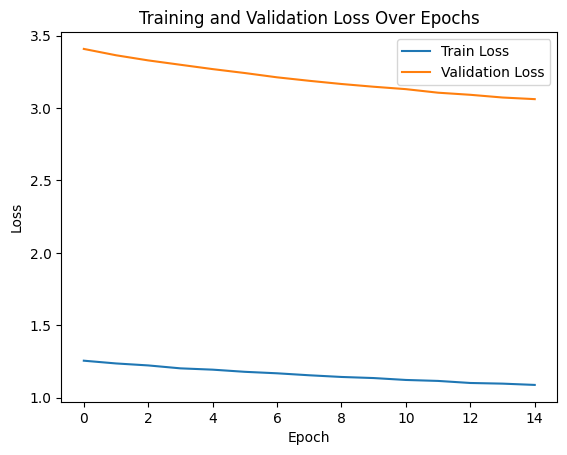

In [37]:
plt.plot(train_loss_history, label = "Train Loss")
plt.plot(val_loss_history, label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss Over Epochs")
plt.show()


### VI. Evaluation and Inference


In [38]:
with open(VOCAB_PATH, "rb") as f:
    vocab = pickle.load(f)

vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)

best_model = Model(EfficientNetEncoder(EMBED_DIM, freeze_backbone = True), Decoder(EMBED_DIM, HIDDEN_DIM, vocab_size, encoder_dim = EMBED_DIM)).to(DEVICE)
best_model.load_state_dict(torch.load(BEST_CHECKPOINT_PATH, map_location = DEVICE)["model_state_dict"])
best_model.eval()


Vocabulary size: 2982


Model(
  (encoder): EfficientNetEncoder(
    (feature_extractor): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
              (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
          

In [39]:
inference_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean = mean, std = std)
])


In [40]:
def generate_caption(image):
    pil_image = image.convert("RGB")
    image_tensor = inference_transform(pil_image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output_indices = best_model.generate(image_tensor, max_len = 50)

    result_words = []
    end_token_index = vocab.stoi["<EOS>"]
    for idx in output_indices:
        if idx == end_token_index:
            break
        word = vocab.itos.get(idx, "<UNK>")
        if word not in ("<SOS>", "<EOS>", "<PAD>"):
            result_words.append(word)

    caption = " ".join(result_words)
    return caption


In [41]:
def clean_caption(caption):
    """Clean and normalize captions for better evaluation"""
    # Remove extra spaces and normalize
    caption = re.sub(r"\s+", " ", caption.strip())
    return caption.lower()

# Example inference
# generate_caption(Image.open(os.path.join(IMAGE_FOLDER_PATH, "12830823_87d2654e31.jpg")))

In [42]:
from collections import defaultdict

candidate_list = []
reference_list = {}

print("Starting CIDEr-D Evaluation on the test set...")

i = 0
for iid, references in test_dict.items():
    image_path = os.path.join(IMAGE_FOLDER_PATH, iid)
    image = Image.open(image_path)

    candidate = generate_caption(image)
    cleaned_candidate = clean_caption(candidate)

    candidate_list.append({
        "image_id": i,
        "caption": [cleaned_candidate]  # Use cleaned caption
    })

    # Clean and lowercase all reference captions
    reference_list[i] = [clean_caption(ref) for ref in references]
    i += 1

ciderD = CiderD()
final_ciderD = ciderD.compute_score(reference_list, candidate_list)[0]
final_ciderD = final_ciderD * 100
print(f"Final CIDEr-D on test set: {final_ciderD:.4f}")

Starting CIDEr-D Evaluation on the test set...
Final CIDEr-D on test set: 33.8628
